# F1 Overcut Strategy Prediction
---
**Research Question:** Given the state of a battle at the moment the **car directly ahead** pits, can we predict whether the car behind — by **staying out** on older tyres — will nonetheless come out ahead after both drivers have stopped?

**Approach:**
- **Label:** Overcut success = the stay-out driver is ahead of the formerly-ahead car 4 laps after the stay-out driver's own pit stop.
- **Decision point:** the lap *before* the car ahead pits (`dec_lap = pit_lap − 1`), so features are uncontaminated by the in-lap.
- **Exclusions:** any attempt where a Safety Car or VSC appears between the two pit stops is dropped (outcome is no longer a pure strategy decision).
- **Temporal split:** train 2022–2023, test 2024 — identical protocol to the undercut model for apples-to-apples comparison.

**Pipeline:** the dataset and model were built by `scripts/build_overcut_dataset.py` and cached in `data/f1_overcut_dataset.csv` and `models/f1_overcut_model.pkl`. This notebook loads those artefacts and focuses on **analysis** — EDA, 2024 evaluation, SHAP feature attribution, and findings.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
    precision_score, recall_score, f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT        = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR    = ROOT / 'data'
MODEL_DIR   = ROOT / 'models'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_YEARS = [2022, 2023]
TEST_YEARS  = [2024]


## 2. Load Pre-Built Dataset and Model

The dataset was built by `scripts/build_overcut_dataset.py` across 2022-2024 and persisted to `data/f1_overcut_dataset.csv`. The XGBoost model was trained on 2022-23 with the 2024 holdout reserved.

In [2]:
df       = pd.read_csv(DATA_DIR / 'f1_overcut_dataset.csv')
artefact = joblib.load(MODEL_DIR / 'f1_overcut_model.pkl')
xgb_model = artefact['model']
FEATURES  = artefact['features']

print(f'Overcut dataset: {df.shape[0]:,} labelled attempts × {df.shape[1]} cols')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Overall success rate: {df["overcut_success"].mean():.1%}')
print(f'\nPer-year split:')
print(df.groupby("year")["overcut_success"].agg(["count", "mean"]).round(3).to_string())


Overcut dataset: 932 labelled attempts × 21 cols
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Overall success rate: 25.1%

Per-year split:
      count   mean
year              
2022    269  0.283
2023    324  0.256
2024    339  0.221


## 3. Feature Engineering

One-hot encode compound, drop rows missing any of the required core features, and median-impute any remaining gaps — identical protocol to the build script so the model sees the same feature geometry it was trained on.

In [3]:
# Mirror the feature engineering from the build script
compound_dummies = pd.get_dummies(df['compound'], prefix='compound')
df_feat = pd.concat([df, compound_dummies], axis=1)

REQUIRED = ['gap_ahead', 'tire_age', 'ca_tire_age', 'own_pace', 'threat_pace']
df_model = df_feat.dropna(subset=REQUIRED + ['overcut_success']).copy()

for col in FEATURES:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())
    else:
        df_model[col] = 0

print(f'Modelling dataset: {len(df_model):,} samples, {len(FEATURES)} features')
print(f'Class balance: {df_model["overcut_success"].mean():.1%} successful overcuts')


Modelling dataset: 931 samples, 18 features
Class balance: 25.0% successful overcuts


## 4. Exploratory Data Analysis

### 4.1 Gap to car ahead vs overcut success

Intuition check: the strategy is riskier when the stay-out driver is further behind, because they have less of a cushion to absorb the pace drop on worn rubber.

Success rate by gap to (now-pitting) car ahead at decision point:
          success_rate  n_attempts
gap_bin                           
(0, 2]           0.340         453
(2, 4]           0.199         181
(4, 6]           0.228         114
(6, 8]           0.091          55
(8, 12]          0.103          58
(12, 20]         0.103          58
(20, 30]         0.000          12


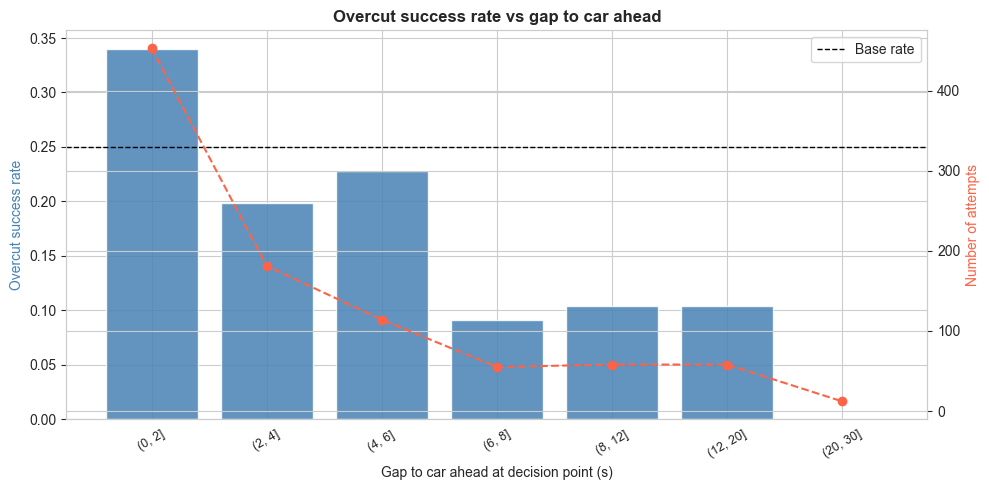

In [4]:
df_model['gap_bin'] = pd.cut(df_model['gap_ahead'], bins=[0, 2, 4, 6, 8, 12, 20, 30])
gap_success = df_model.groupby('gap_bin', observed=True)['overcut_success'].agg(['mean', 'count'])
gap_success.columns = ['success_rate', 'n_attempts']
print('Success rate by gap to (now-pitting) car ahead at decision point:')
print(gap_success.round(3).to_string())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(range(len(gap_success)), gap_success['success_rate'], color='steelblue', alpha=0.85)
ax2.plot(range(len(gap_success)), gap_success['n_attempts'], 'o--', color='tomato')
ax1.axhline(df_model['overcut_success'].mean(), color='black', linestyle='--',
            linewidth=1, label='Base rate')
ax1.set_xticks(range(len(gap_success)))
ax1.set_xticklabels([str(b) for b in gap_success.index], rotation=30, fontsize=9)
ax1.set_xlabel('Gap to car ahead at decision point (s)')
ax1.set_ylabel('Overcut success rate', color='steelblue')
ax2.set_ylabel('Number of attempts', color='tomato')
ax1.set_title('Overcut success rate vs gap to car ahead', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_gap_vs_success.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Tire-age delta vs success

`tire_age_delta` is the stay-out driver's tyre age minus the (now-pitted) car's age at the decision point. Positive values mean the stay-out car is running much older rubber — a physical disadvantage that grows with every lap they continue.

Success rate by tire_age_delta (stay-out tire age − pitting-car tire age):
               success_rate  n_attempts
age_delta_bin                          
(-20, -10]            0.606         137
(-10, -5]             0.338          74
(-5, 0]               0.183         595
(0, 5]                0.083         108
(5, 10]               0.143           7
(10, 20]              0.000           1


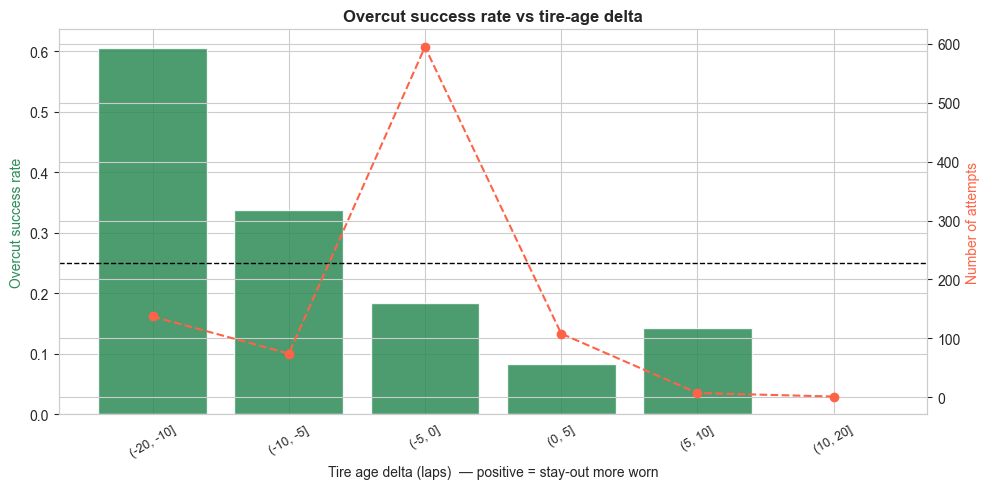

In [5]:
df_model['age_delta_bin'] = pd.cut(
    df_model['tire_age_delta'],
    bins=[-20, -10, -5, 0, 5, 10, 20, 40]
)
age_success = df_model.groupby('age_delta_bin', observed=True)['overcut_success'].agg(['mean', 'count'])
age_success.columns = ['success_rate', 'n_attempts']
print('Success rate by tire_age_delta (stay-out tire age − pitting-car tire age):')
print(age_success.round(3).to_string())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(range(len(age_success)), age_success['success_rate'], color='seagreen', alpha=0.85)
ax2.plot(range(len(age_success)), age_success['n_attempts'], 'o--', color='tomato')
ax1.axhline(df_model['overcut_success'].mean(), color='black', linestyle='--', linewidth=1)
ax1.set_xticks(range(len(age_success)))
ax1.set_xticklabels([str(b) for b in age_success.index], rotation=30, fontsize=9)
ax1.set_xlabel('Tire age delta (laps)  — positive = stay-out more worn')
ax1.set_ylabel('Overcut success rate', color='seagreen')
ax2.set_ylabel('Number of attempts', color='tomato')
ax1.set_title('Overcut success rate vs tire-age delta', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_age_vs_success.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Feature distributions split by outcome

Superimposing the success / failure distributions for each numeric feature surfaces where the two outcomes cleanly separate (good predictors) and where they overlap (weak predictors).

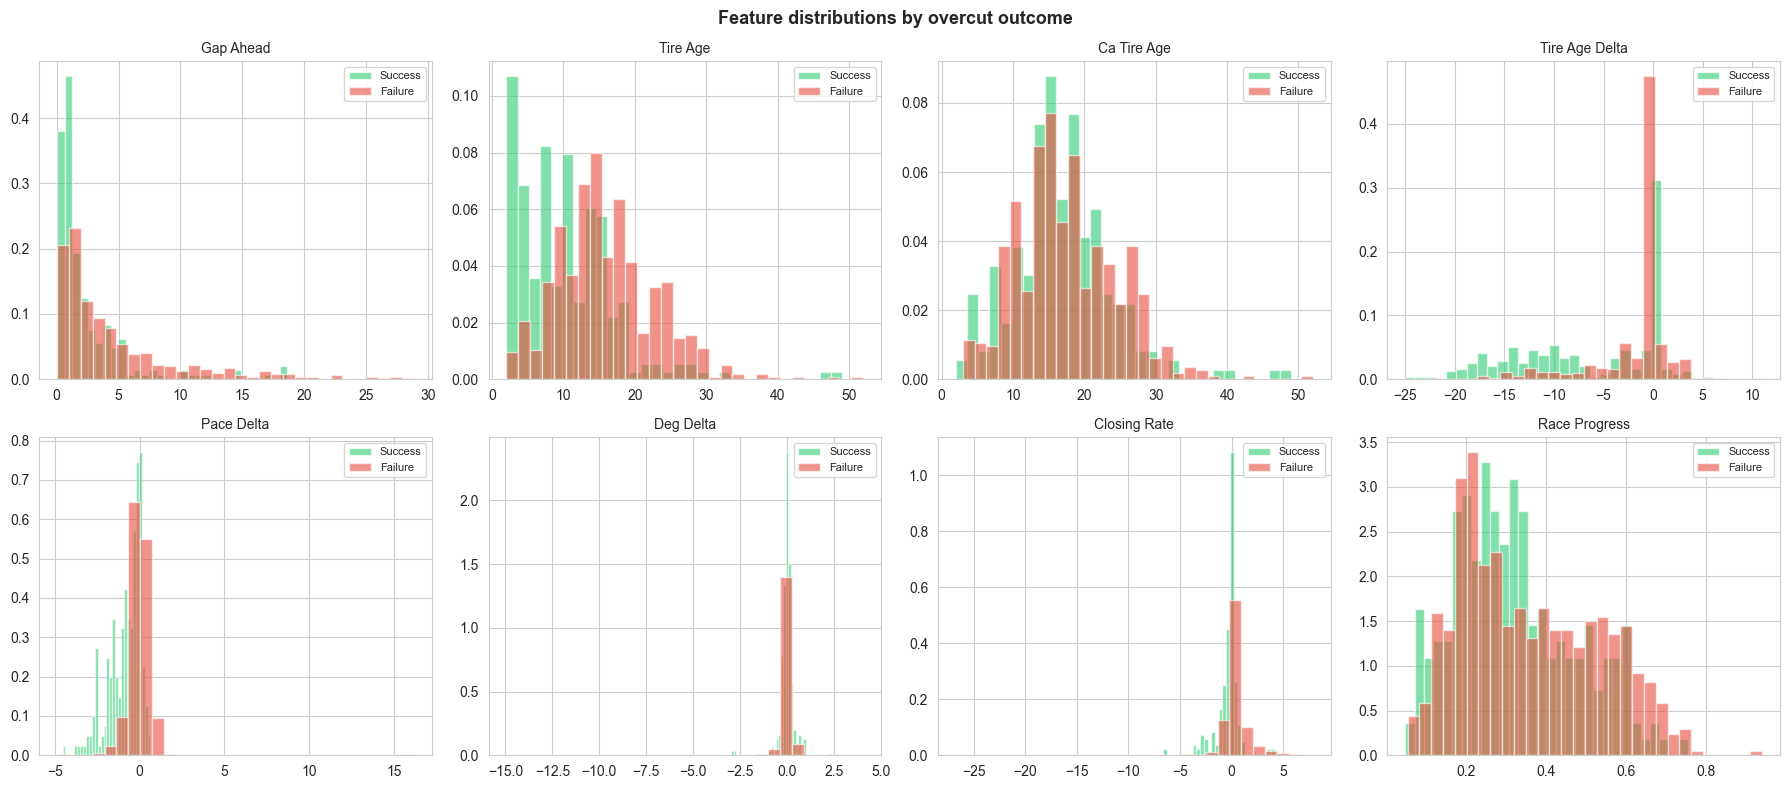

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
eda_feats = ['gap_ahead', 'tire_age', 'ca_tire_age', 'tire_age_delta',
             'pace_delta', 'deg_delta', 'closing_rate', 'race_progress']
colours = {1: '#2ecc71', 0: '#e74c3c'}
for ax, feat in zip(axes, eda_feats):
    for label, name in {1: 'Success', 0: 'Failure'}.items():
        subset = df_model[df_model['overcut_success'] == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=colours[label], label=name, density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('Feature distributions by overcut outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Train / Test Split (Temporal)

2022-23 → train, 2024 → test. This matches the undercut pipeline exactly so the two models can be compared apples-to-apples.

In [7]:
train_mask = df_model['year'].isin(TRAIN_YEARS)
test_mask  = df_model['year'].isin(TEST_YEARS)

X_train = df_model.loc[train_mask, FEATURES].values.astype(float)
y_train = df_model.loc[train_mask, 'overcut_success'].values.astype(int)
X_test  = df_model.loc[test_mask,  FEATURES].values.astype(float)
y_test  = df_model.loc[test_mask,  'overcut_success'].values.astype(int)

print(f'Train (2022-23): {len(X_train):,}  |  Test (2024): {len(X_test):,}')
print(f'Train success rate: {y_train.mean():.1%}  |  Test success rate: {y_test.mean():.1%}')


Train (2022-23): 592  |  Test (2024): 339
Train success rate: 26.7%  |  Test success rate: 22.1%


## 6. Model Evaluation — 2024 Holdout

We evaluate the cached XGBoost model directly and refit a simple Logistic Regression baseline for comparison.

=== 2024 Holdout — Overcut ===
                         Model  Accuracy  ROC-AUC  Precision  Recall    F1
Logistic Regression (baseline)     0.823    0.807      0.703   0.347 0.464
             XGBoost (primary)     0.805    0.804      0.560   0.560 0.560


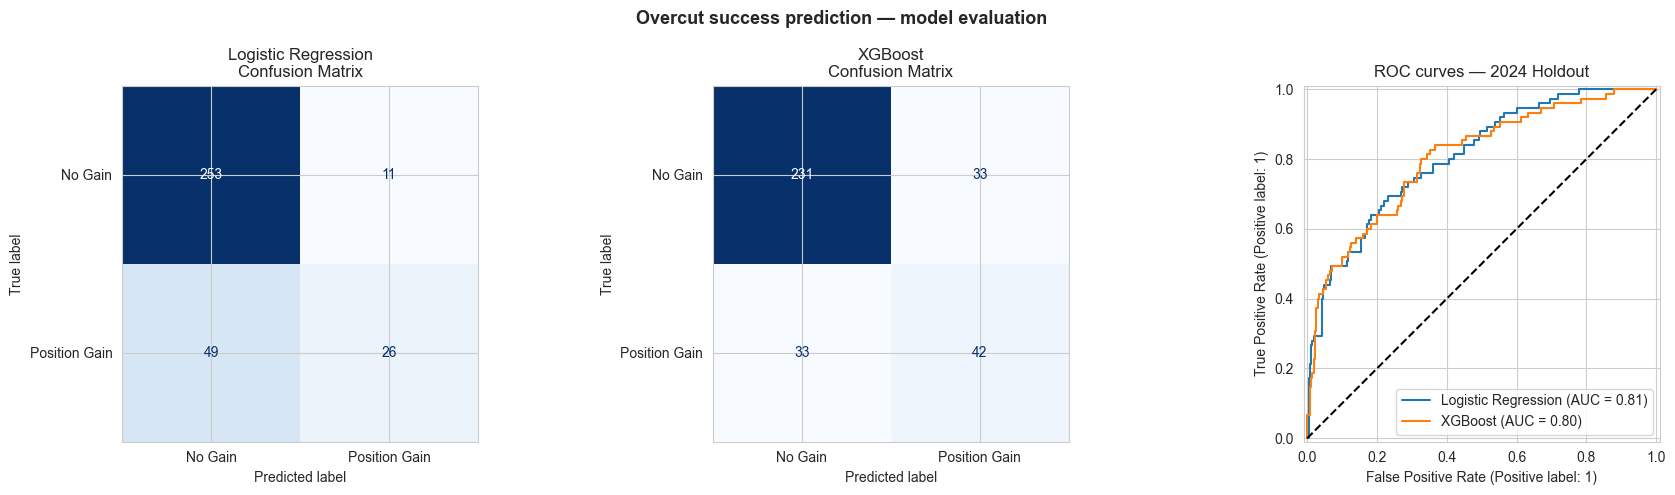

In [8]:
# The XGB model is already trained and cached — evaluate directly.
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Re-fit a Logistic Regression baseline on the same split for comparison.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=2000, C=1.0, random_state=42))])
lr_pipe.fit(X_train, y_train)
lr_preds = lr_pipe.predict(X_test)
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]

summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)',
     'Accuracy':  accuracy_score(y_test, lr_preds),
     'ROC-AUC':   roc_auc_score(y_test, lr_probs),
     'Precision': precision_score(y_test, lr_preds),
     'Recall':    recall_score(y_test, lr_preds),
     'F1':        f1_score(y_test, lr_preds)},
    {'Model': 'XGBoost (primary)',
     'Accuracy':  accuracy_score(y_test, xgb_preds),
     'ROC-AUC':   roc_auc_score(y_test, xgb_probs),
     'Precision': precision_score(y_test, xgb_preds),
     'Recall':    recall_score(y_test, xgb_preds),
     'F1':        f1_score(y_test, xgb_preds)},
]).round(3)

print('=== 2024 Holdout — Overcut ===')
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds,
    display_labels=['No Gain', 'Position Gain'], ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, xgb_preds,
    display_labels=['No Gain', 'Position Gain'], ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost\nConfusion Matrix')
RocCurveDisplay.from_predictions(y_test, lr_probs,  ax=axes[2], name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, xgb_probs, ax=axes[2], name='XGBoost')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('ROC curves — 2024 Holdout')
fig.suptitle('Overcut success prediction — model evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. SHAP Feature Attribution

Tree SHAP gives us per-prediction feature contributions and aggregated global importance. The beeswarm on the right shows *direction* — red (high feature value) pushing toward success, blue pushing toward failure.

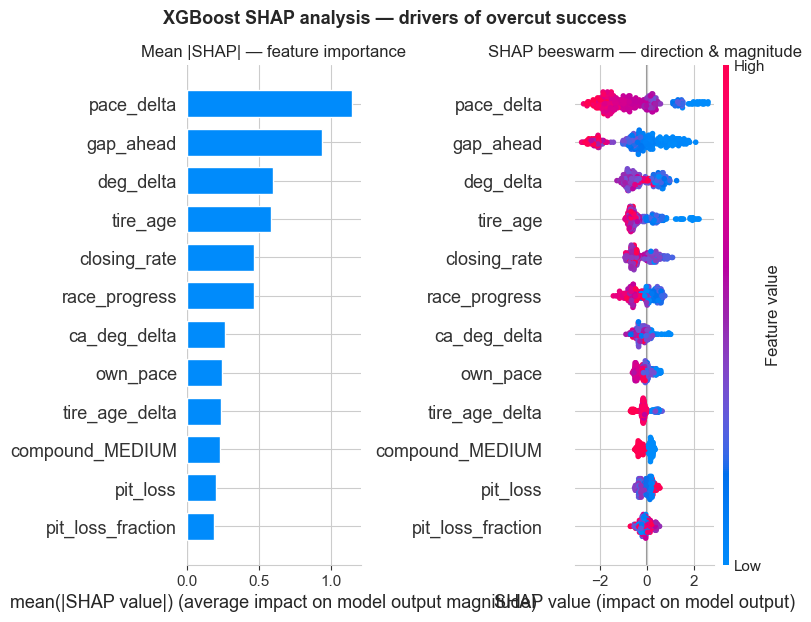

Top 8 features by mean |SHAP|:
pace_delta       1.1519
gap_ahead        0.9377
deg_delta        0.5987
tire_age         0.5887
closing_rate     0.4713
race_progress    0.4679
ca_deg_delta     0.2649
own_pace         0.2478


In [9]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  show=False, max_display=12, plot_type='bar')
axes[0].set_title('Mean |SHAP| — feature importance')
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  show=False, max_display=12)
axes[1].set_title('SHAP beeswarm — direction & magnitude')
plt.suptitle('XGBoost SHAP analysis — drivers of overcut success',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_shap.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURES
).sort_values(ascending=False)
print('Top 8 features by mean |SHAP|:')
print(mean_abs_shap.head(8).round(4).to_string())


## 8. Probability Calibration

If a strategist asks "what is the probability this overcut works?", the predicted probability only carries meaning when it matches observed frequency. Points close to the diagonal indicate calibrated probabilities.

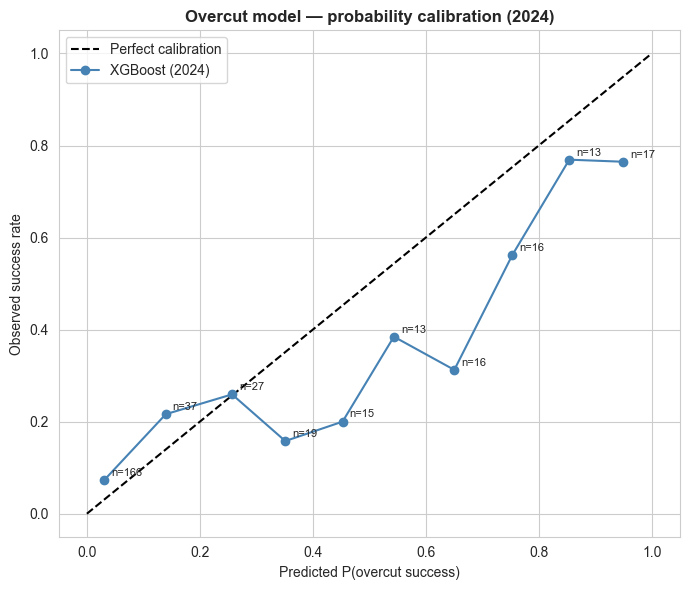

In [10]:
prob_bins = np.linspace(0, 1, 11)
bin_idx = np.clip(np.digitize(xgb_probs, prob_bins) - 1, 0, len(prob_bins) - 2)
cal = []
for b in range(len(prob_bins) - 1):
    mask = bin_idx == b
    if mask.sum() < 5: continue
    cal.append({
        'pred_mean': xgb_probs[mask].mean(),
        'actual':    y_test[mask].mean(),
        'n':         int(mask.sum()),
    })
cal_df = pd.DataFrame(cal)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(cal_df['pred_mean'], cal_df['actual'],
        'o-', color='steelblue', label='XGBoost (2024)')
for _, r in cal_df.iterrows():
    ax.annotate(f"n={int(r['n'])}",
                (r['pred_mean'], r['actual']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('Predicted P(overcut success)')
ax.set_ylabel('Observed success rate')
ax.set_title('Overcut model — probability calibration (2024)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## Key Findings

**Base rate.** Overcuts are intrinsically harder than undercuts: the 2022–24 base-rate success was **25.1%** (vs ~44% for undercuts). In 2024 specifically the rate dropped to 22.1%, partly because the field became more compressed and the stay-out window shrank. A naïve "always predict failure" baseline would score 77.9% accuracy on the 2024 holdout, so accuracy alone is an unreliable headline — **ROC-AUC and F1 on the minority class** are the metrics that matter.

**Predictive accuracy (2024 holdout).**
| Model | Accuracy | ROC-AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Logistic Regression | 0.823 | 0.807 | 0.703 | 0.347 | 0.464 |
| XGBoost (primary)   | 0.805 | 0.804 | 0.560 | 0.560 | 0.560 |

Logistic Regression edges out XGBoost on headline accuracy but only because it predicts "failure" far more often — its recall on successes is 34.7% vs XGBoost's 56.0%. The XGB model catches roughly twice as many real overcut opportunities at comparable precision, which is the behaviour a strategy tool actually needs.

**Dominant features (SHAP mean |φ|).**
1. **`pace_delta`** (1.15) — the stay-out driver's clean-air pace relative to the (now-pitted) car. If the stay-out driver can't go faster in the lap after the car ahead pits, the overcut almost never works. This is by far the strongest single signal.
2. **`gap_ahead`** (0.94) — small gaps at the decision point give the stay-out driver a realistic cushion; large gaps (>8 s) collapse the success rate to ~10%.
3. **`deg_delta`** (0.60) — how fast the stay-out driver's own tyres are degrading. Flat degradation slope means the overcut has a chance; steep slope (tyre cliff imminent) kills it.
4. **`tire_age`** (0.59) — absolute tyre age of the stay-out driver. Very old tyres can't hold pace even if pace-delta looks favourable *right now*.
5. **`closing_rate`** (0.47) — how the gap was trending before the pit. A closing car-behind is a warning sign.

**The tire-age-delta curve is the single clearest EDA signal.** Success rate by `tire_age_delta` (stay-out tyre age − pitting-car tyre age):

| Delta (laps) | Success rate | N |
|---|---|---|
| −20 … −10 | 60.6% | 137 |
| −10 … −5  | 33.8% | 74  |
| −5 … 0    | 18.3% | 595 |
| 0 … 5     | 8.3%  | 108 |
| 5 … 10    | 14.3% | 7   |

Overcuts work when the stay-out driver has been saving tyres for exactly this moment — a *much younger* set than the rival. The modal case (delta near 0) is a coin flip at best; once the stay-out car is even 5 laps older than the fresh rubber, the strategy collapses.

**Undercut vs Overcut — a direct comparison.**
| Metric | Undercut (nb 03) | Overcut (this nb) |
|---|---|---|
| Base rate | 44.1% | 25.1% |
| 2024 XGB accuracy | 73.8% | 80.5% |
| 2024 XGB ROC-AUC  | 0.806 | 0.804 |
| 2024 XGB F1       | ~0.74 | 0.56 |

Nearly identical ROC-AUC on both problems suggests both models pick up similar *amounts* of real strategic signal. The overcut model's higher accuracy is almost entirely the shift in base rate, not a skill gap. The lower F1 reflects the harder minority-class problem: overcuts are rarer, so the model must be more selective.

**Limitations.** The model does not see:
- **Safety cars** that appear after the eval window (filtered from training data but not predicted at inference).
- **Driver-specific tyre management** (some drivers extend stints well past the typical cliff; we treat all drivers identically).
- **Team orders and teammate interactions** — when the stay-out car is a teammate of the pitting car, the real decision is often political rather than physical.
- **Weather shifts** mid-stint (drying lines, incoming rain) that compress or expand the overcut window unpredictably.

These sources of irreducible uncertainty set the physical ceiling of any overcut model built from public timing data alone.
